In [1]:
include("CRD_STA.jl")
include("Fun.jl")
using LinearAlgebra
using NonlinearEigenproblems
using DelimitedFiles
using DifferentialEquations
using Plots
using Arpack

In [2]:
function BF(N_cheb,Ro,Tw,Mr)
    gamma = 1.4
    sigma = 0.72
    Co = 2 - Ro - Ro^2
    u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    return F,G,H,T,rho,x,lam,kappa,D,D2
end
function eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
    cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
    L0,L1,L2 = assemble_mat(cof,D,D2,be,omega)
    nep = PEP([L0,L1,L2]); 
    eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-12)
    # eigval = conj(eigval)
    return cof,eigval,eigvec
end
function integral(x,y)
    inte_progress =  zeros(ComplexF64,length(x),1)
    for i = 1 : length(x)
        inte_progress[i] = x[1:i,1]' * y[1:i,1]
    end
    return inte_progress
end
function mat_diff(A,B,N_cheb)
    block_size = N_cheb + 1
    nblock = 5
    C = zeros(ComplexF64,block_size*nblock,block_size*nblock)
    for i = 0 : nblock - 1
        for j = 0 : nblock - 1
        C[1+block_size*i:block_size*(i+1),1+block_size*j:block_size*(j+1)] = (B * A[1+block_size*i:block_size*(i+1),1+block_size*j:block_size*(j+1)])
        end
    end

    return C'
end
function eig_full(eigvec,N_cheb,num)
    N = N_cheb + 1
    eigvec = eigvec[:,num]
    insert!(eigvec,5N-8,0im)
    insert!(eigvec,4N-6,0im)
    insert!(eigvec,4N-6,0im)
    insert!(eigvec,3N-4,0im)
    insert!(eigvec,3N-4,0im)
    insert!(eigvec,2N-2,0im)
    insert!(eigvec,2N-2,0im)
    insert!(eigvec,N,0im)
    insert!(eigvec,N,0im)
    rho = eigvec[1:N]
    u = eigvec[N+1:2N]
    v = eigvec[2N+1:3N]
    w = eigvec[3N+1:4N]
    T = eigvec[4N+1:5N]
    return eigvec,(rho,u,v,w,T)
end

eig_full (generic function with 1 method)

In [3]:
function Bi_linear(C,H1_A,vec_A)
    q_all = []
    for i = 1 : size(C.vectors,2)
        Q = (vec_A') * (H1_A' * C.vectors[:,i])
        q_all = [q_all ; Q]
    end 
    ind = findmax(abs.(q_all))
    Q = q_all[ind[2]]
    return q_all,Q,C.values[ind[2]]
end

Bi_linear (generic function with 1 method)

In [4]:
N_cheb = 99
Ro = -1
Tw = 1.0
Mr = 0.3
gamma = 1.4
sigma = 0.72
Co = 2-Ro-Ro^2
F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)

([0.0; 0.0016902914174871555; … ; 6.744959925293321e-24; 6.744959925293321e-24;;], [0.0; -0.00204706964530085; … ; -1.0; -1.0;;], [-3.176003061707337e-25; -5.624114047390512e-6; … ; -0.884473922139928; -0.884473922139928;;], [1.0; 1.0000278713200565; … ; 0.9999997873656139; 0.9999997873656139;;], [1.0; 0.9999721294567323; … ; 1.0000002126344314; 1.0000002126344314;;], [0.0; 0.003323595880920774; … ; 40.0; 40.0;;], [-0.6666666666666666; -0.6666852475467043; … ; -0.6666665249104092; -0.6666665249104092;;], [1.3888888888888888; 1.388927599055634; … ; 1.3888885935633526; 1.3888885935633526;;], [-495.02525252518734 601.8983384289603 … -0.1515533018472357 0.07575757575757575; -150.40437039833355 75.18324987611669 … 0.07576036801362229 -0.03787064607225595; … ; 7.3947244003375096e-9 -1.4793173606280373e-8 … -1.4680483963619082e-5 2.9368362651641038e-5; -0.0 0.0 … -0.0 0.0], [147083.37513538264 -233710.3644859559 … 149.56185849737366 -74.76180398615428; 67891.81641762426 -97071.1578953374 … 11

In [5]:
n = 30
num = 1
R = 300
omega = 0.0/R
be = n/R
Ma = Mr/R
c = 0.5
cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
L0_raw,L1_raw,L2_raw= assemble_mat(cof,D,D2,be,omega)
L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb)
nep = PEP([L0,L1,L2]);
eigval,eigvec = iar(nep, σ = c, neigs = 1,maxit = 500 , tol=1e-12)
vel_full,vel = eig_full(eigvec,N_cheb,1)

(ComplexF64[1.1543059094362265e-10 + 7.470776995080128e-9im, -3.6057967531441458e-6 - 1.4318849380538052e-6im, -1.4428154432689914e-5 - 5.751709990743301e-6im, -3.247843804838883e-5 - 1.2954530608251047e-5im, -5.775577760745852e-5 - 2.3025037960689724e-5im, -9.017796626134679e-5 - 3.587319735190973e-5im, -0.00012941865833900556 - 5.1226875514563e-5im, -0.0001746121011733694 - 6.849750861232982e-5im, -0.00022391601727525358 - 8.669049574273023e-5im, -0.0002739810317631783 - 0.00010446232643279912im  …  -2.801939601256747e-13 + 9.535297898488615e-14im, 8.251347754637111e-14 - 1.753684816720863e-14im, 1.2895289675399164e-14 - 7.015448741680072e-15im, 3.3797713578344e-13 - 1.758513040045484e-13im, 2.0373535058959503e-13 - 1.0025471121680174e-13im, 1.0929971559224446e-13 - 3.772749799201003e-14im, 1.2815066868408725e-13 - 5.189868052400911e-14im, -3.567012084276933e-13 + 1.598215776724283e-13im, -1.369996377606705e-13 + 6.63137517333798e-14im, 0.0 + 0.0im], (ComplexF64[1.1543059094362265e-1

In [6]:
A0_raw = transpose(cof.D1) + (im * be * transpose(cof.B)) - (im * omega * transpose(cof.Ta)) - (be^2 * transpose(cof.Vyy)) - transpose(cof.dC) - (im *be*transpose(cof.dVyz)) + transpose(cof.d2Vzz) - (transpose(cof.C) + im * be * transpose(cof.Vyz) - 2 * transpose(cof.dVzz)) * kron(I(5),D) + transpose(cof.Vzz) * kron(I(5),D2)
A1_raw = (im * transpose(cof.A)) - (be * transpose(cof.Vxy)) - (im * transpose(cof.dVxz)) - (im * transpose(cof.Vxz)) * kron(I(5),D) 
A2_raw = -transpose(cof.Vxx)
L0_A = A0_raw[setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
L1_A = A1_raw[setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
L2_A = A2_raw[setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
nep = PEP([L0_A,L1_A,L2_A]);
eigval_A,eigvec_A = iar(nep,σ = c, neigs = 3 ,maxit = 500,tol = 1e-14)
vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1) 
@show eigval,eigval_A

(eigval, eigval_A) = (ComplexF64[0.5114353560762994 + 0.00949559666034496im], ComplexF64[0.5114355375071342 + 0.00949597214717832im, 0.2980389901879056 + 0.12321057299844859im, 0.2760326700344983 + 0.07336044884567339im])


(ComplexF64[0.5114353560762994 + 0.00949559666034496im], ComplexF64[0.5114355375071342 + 0.00949597214717832im, 0.2980389901879056 + 0.12321057299844859im, 0.2760326700344983 + 0.07336044884567339im])

In [7]:
A0_raw = transpose(cof.D1) + (-im * be * transpose(cof.B)) - (-im * omega * transpose(cof.Ta)) - (be^2 * transpose(cof.Vyy)) - transpose(cof.dC) - (-im *be*transpose(cof.dVyz)) + transpose(cof.d2Vzz) - (transpose(cof.C) + -1 * im * be * transpose(cof.Vyz) - 2 * transpose(cof.dVzz)) * kron(I(5),D) + transpose(cof.Vzz) * kron(I(5),D2)
A1_raw = (-im * transpose(cof.A)) - (be * transpose(cof.Vxy)) - (-im * transpose(cof.dVxz)) - (-im * transpose(cof.Vxz)) * kron(I(5),D) 
A2_raw = -transpose(cof.Vxx)
L0_A = A0_raw[setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
L1_A = A1_raw[setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
L2_A = A2_raw[setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
nep = PEP([L0_A,L1_A,L2_A]);
eigval_A,eigvec_A = iar(nep,σ = c, neigs = 3 ,maxit = 500,tol = 1e-13)
vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1) 
@show eigval,eigval_A

(eigval, eigval_A) = (ComplexF64[0.5114353560762994 + 0.00949559666034496im], ComplexF64[0.5114355375072746 - 0.009495972146960728im, 0.27603267003690607 - 0.07336044884610432im, 0.29803899029837233 - 0.12321057306450652im])


(ComplexF64[0.5114353560762994 + 0.00949559666034496im], ComplexF64[0.5114355375072746 - 0.009495972146960728im, 0.27603267003690607 - 0.07336044884610432im, 0.29803899029837233 - 0.12321057306450652im])

In [ ]:
function Wcc_fun(z,N_cheb)
    Wcc = zeros(N_cheb + 1,N_cheb + 1)
    for i = 1 : 1 : N_cheb
        if i == 1
            Wcc[i,i] = (z[2] - z[1])/2
        elseif i == N_cheb + 1
            Wcc[i,i] = (z[i] - z[i-1])/2
        else
            Wcc[i,i] = (z[i+1] - z[i-1])/2
        end
    end
    W = kron(I(5),Wcc)
    W = W[setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))];
    W_H = kron(I(2),W);
    return W,W_H
end

Wcc_fun (generic function with 1 method)

In [9]:
q_all = []
W,W_H = Wcc_fun(z,N_cheb)
W =  W
for i = 1 : length(eigval_A)
    Q = transpose(eigvec_A[:,i]) * W  * (L1 + (eigval[1]+eigval_A[i]) * L2) * eigvec[:,1]
    push!(q_all,Q)
end
abs.(q_all)

3-element Vector{Float64}:
 0.7139780651432833
 1.4707630729282486
 0.021897236153917084

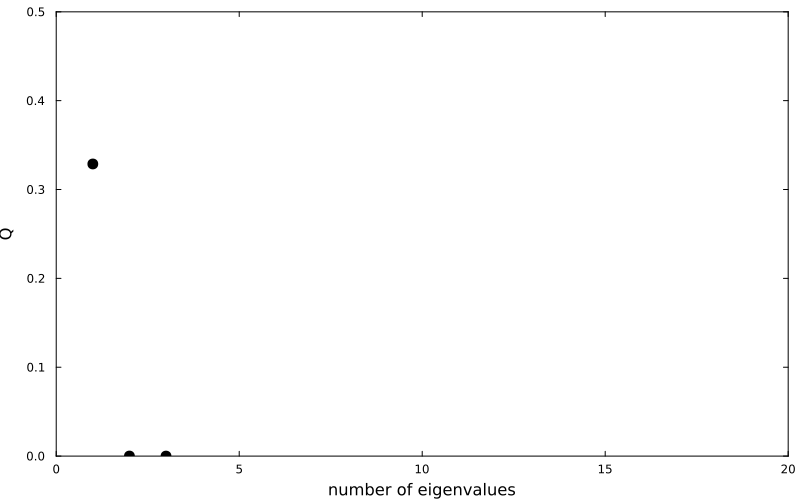

In [15]:
scatter(abs.(q_all),xlims=[0,20],ylims=[0,0.5],size=(800,500),markersize=abs.(6),mc=:black,grid=false,label=false ,framestyle=:box,xlabel="number of eigenvalues", ylabel="Q")

In [ ]:
plot(z,abs.(vel[1]),label = "rho",xlims=[0,8]) 
plot!(z,abs.(vel[2]),label = "u",xlims=[0,8])
plot!(z,abs.(vel[3]),label = "v")
plot!(z,abs.(vel[4]),label = "w")
plot!(z,abs.(vel[5]),label = "T") 

In [ ]:
plot(z,abs.(vel_A[1]),label = "rho",xlims=[0,8]) 
plot!(z,abs.(vel_A[2]),label = "u",xlims=[0,8])
plot!(z,abs.(vel_A[3]),label = "v")
plot!(z,abs.(vel_A[4]),label = "w")
plot!(z,abs.(vel_A[5]),label = "T") 

In [45]:
function assemble_adjmat(cof,D,D2,be,omega)
        A0_raw = transpose(cof.D1) + (im * be * transpose(cof.B)) - (im * omega * transpose(cof.Ta)) - (be^2 * transpose(cof.Vyy)) - transpose(cof.dC) - (im *be*transpose(cof.dVyz)) + transpose(cof.d2Vzz) - (transpose(cof.C) + im * be * transpose(cof.Vyz) - 2 * transpose(cof.dVzz)) * kron(I(5),D) + transpose(cof.Vzz) * kron(I(5),D2)
        A1_raw = (im * transpose(cof.A)) - (be * transpose(cof.Vxy)) - (im * transpose(cof.dVxz)) - (im * transpose(cof.Vxz)) * kron(I(5),D) 
        A2_raw = -transpose(cof.Vxx)
        # A0_raw = transpose(cof.D1) + (-im * be * transpose(cof.B)) - (-im * omega * transpose(cof.Ta)) - (be^2 * transpose(cof.Vyy)) - transpose(cof.dC) - (-im *be*transpose(cof.dVyz)) + transpose(cof.d2Vzz) - (transpose(cof.C) + -1 * im * be * transpose(cof.Vyz) - 2 * transpose(cof.dVzz)) * kron(I(5),D) + transpose(cof.Vzz) * kron(I(5),D2)
        # A1_raw = (-im * transpose(cof.A)) - (be * transpose(cof.Vxy)) - (-im * transpose(cof.dVxz)) - (-im * transpose(cof.Vxz)) * kron(I(5),D) 
        # A2_raw = -transpose(cof.Vxx)
    return A0_raw,A1_raw,A2_raw
end
function pre_process(n,R,Mr,OMEGA,N_cheb,c,F,G,H,T,rho,z,lam,kappa,D,D2)
    omega = OMEGA/R
    be = n/R
    Ma = Mr/R
    cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
    L0_raw,L1_raw,L2_raw= assemble_mat(cof,D,D2,be,omega)
    L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb)
    A0_raw,A1_raw,A2_raw = assemble_adjmat(cof,D,D2,be,omega)
    L0_A,L1_A,L2_A = boudary_condition(A0_raw,A1_raw,A2_raw,N_cheb)
    nep = PEP([L0,L1,L2]);
    nep = PEP([L0_A,L1_A,L2_A]); 
    eigval,eigvec = iar(nep, σ = c, neigs = 1,maxit = 500 , tol=1e-12)
    vel_full,vel = eig_full(eigvec,N_cheb,1)
    eigval_A,eigvec_A = iar(nep,σ = c, neigs = 1 ,maxit = 500,tol = 1e-14)
    return eigval[1],eigval_A[1]
end


pre_process (generic function with 1 method)

In [ ]:
function eigvec_ref()
    N_cheb = 199
    Ro = -1
    Tw = 1
    Mr = 0.3
    gamma = 1.4
    sigma = 0.72
    Co = 2-Ro-Ro^2
    OMEGA = 0
    F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)
    # for n = 30
    n = 60
        R_start,R_step,R_end = 400,4,500
        num = 1
        data = [0 0 0 0 0 0]
        W,W_H = Wcc_fun(z,N_cheb)
        c,c_A = pre_process(n,R_start,Mr,OMEGA,N_cheb,0.8)
        for R = R_start : R_step : R_end
            omega = 0/R
            be = n/R
            Ma = Mr/R
            cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
            L0_raw,L1_raw,L2_raw= assemble_mat(cof,D,D2,be,omega)
            L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb)
            A0_raw,A1_raw,A2_raw = assemble_adjmat(cof,D,D2,be,omega)
            L0_A,L1_A,L2_A = boudary_condition(A0_raw,A1_raw,A2_raw,N_cheb)

            # H0 = [Zero -eye;L0 L1]
            # H1 = [-eye Zero; Zero -L2]
            # H0_A = [Zero -eye;L0_A L1_A]
            # H1_A = [-eye Zero; Zero -L2_A]
            # C = eigs(H0,H1,nev=1,maxiter = 500,sigma = c, which=:SI)
            # C_A = eigs(H0_A,H1_A,nev=1,maxiter = 500,sigma = c_A, which=:SI)
            # vec_half = C[2][1:5*N_cheb-4,1]
            # vec_A_half = C_A[2][1:5*N_cheb-4,1]
            # vel_full,vel = eig_full(vec_half,N_cheb,1)
            # vel_full_A,vel_A = eig_full(vec_A_half,N_cheb,1)
            # eigval = C[1]
            # eigval_A = C_A[1]
            # c_A =  eigval_A[1]
            # c = eigval[1]

            nep = PEP([L0,L1,L2]);
            nep1 = PEP([L0_A,L1_A,L2_A]); 
            eigval,eigvec = iar(nep, σ = c, neigs = 1,maxit = 500 , tol=1e-12)
            vel_full,vel = eig_full(eigvec,N_cheb,1)
            eigval_A,eigvec_A = iar(nep1,σ = c, neigs = 1 ,maxit = 500,tol = 1e-14)
            c = real(eigval[1])
            vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1)
            # data = [data;[R findmax(abs.(vel_A[2]))[1] findmax(abs.((vel_A[3])))[1] findmax(abs.((vel_A[4])))[1]]]
            data = [data ; [R eigval eigval_A (1/R)abs.(D*vel_A[2])[1] (1/R)abs.(D*vel_A[3])[1] (1/R)abs.(D*vel_A[4])[2]]]
            writedlm("log_$(n).dat",data[2:end,:])
        end
    # end
    return data
end
data = eigvec_ref()

In [72]:
function caculate_cr1()
    N_cheb = 199
    Ro = -1
    Tw = 1.0
    Mr = 0.3
    gamma = 1.4
    sigma = 0.72
    Co = 2-Ro-Ro^2
    num = 1
    F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)
    W,W_H = Wcc_fun(z,N_cheb)
    R_start,R_step,R_end = 300,4,340
    OMEGA = 7.9
    Zero = zeros(size(L0,1),size(L0,2))
    eye = I
    n = 30
    c,c_A = pre_process(n,R_start,Mr,OMEGA,N_cheb,0.8,F,G,H,T,rho,z,lam,kappa,D,D2)

        coff = [0 0 0 0 0 0 0 0 0]
        c = 0.9
        for R = R_start : R_step : R_end
            omega = OMEGA/R
            be = n/R
            Ma = Mr/R
            hr = 1;
            ls = 1/2;
            cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
            L0_raw,L1_raw,L2_raw= assemble_mat(cof,D,D2,be,omega)
            L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb)
            A0_raw,A1_raw,A2_raw = assemble_adjmat(cof,D,D2,be,omega)
            L0_A,L1_A,L2_A = boudary_condition(A0_raw,A1_raw,A2_raw,N_cheb)

            nep = PEP([L0,L1,L2]);
            nep1 = PEP([L0_A,L1_A,L2_A]); 
            eigval,eigvec = iar(nep, σ = c, neigs = 1,maxit = 500 , tol=1e-12)
            vel_full,vel = eig_full(eigvec,N_cheb,1)
            eigval_A,eigvec_A = iar(nep1,σ = c, neigs = 1 ,maxit = 500,tol = 1e-12)        
            vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1)
            c = real(eigval[1])
            eigvec = eigvec./findmax(abs.(vel[3]))[1]
            eigvec_A = eigvec_A./findmax(abs.(vel_A[2]))[1]
            vel_full,vel = eig_full(eigvec,N_cheb,1)  
            vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1)
            # Q = ((eigvec_A[:,1]') * W * (L1 + (eigval[1] + eigval_A[1]') * L2) * eigvec[:,1])
            Q = transpose(eigvec_A[:,1]) * W * (L1 + (eigval[1] + eigval_A[1]) * L2) * eigvec[:,1]
            Hx = hr*exp(-(eigval[1])^2/(4*ls))*sqrt(pi/ls)
            u_wall = -(D*F)[1] * Hx
            v_wall = -(D*G)[1] * Hx
            w_wall = 0
            rho_wall = -(D*rho)[1] * Hx 
            T_wall = -(D*T)[1] * Hx 
            item_2 = rho[1] * (D*vel_A[2])[1] * u_wall
            item_3 = rho[1] * (D*vel_A[3])[1] * v_wall
            item_5 = rho[1]^2 * (T[1]/sigma) * (D*vel_A[5])[1] * T_wall
            BC =  item_2 + item_3 + item_5
            Cr = abs(-im * BC/Q[1])
            # coff = [coff;[R Cr real(eigval) imag(eigval) abs(Q[1]) abs(BC)]]
            coff = [coff;[n R Cr abs(Q[1]) abs(BC) real(eigval) imag(eigval) real(eigval_A) imag(eigval_A)]]
            writedlm("Cr_ref_$(n)_$(OMEGA).dat",coff[2:end,:])
        end
    return coff
end
coff = caculate_cr1();

In [ ]:
OMEGA=0 -> 2.5
OMEGA=5 -> 2.87
OMEGA=7.9 -> 3

12×9 Matrix{Float64}:
  0.0    0.0  0.0       0.0      0.0       …  0.0        0.0       0.0
 30.0  300.0  0.1918    3.34491  0.641552     0.0512911  0.729347  0.0512891
 30.0  304.0  0.192925  3.37647  0.651405     0.048558   0.721195  0.0485515
 30.0  308.0  0.193916  3.41045  0.661342     0.0458713  0.713216  0.0458728
 30.0  312.0  0.194883  3.44501  0.671373     0.0432467  0.705404  0.0432507
 30.0  316.0  0.195831  3.48003  0.681497  …  0.040683   0.697752  0.0406832
 30.0  320.0  0.196726  3.51616  0.69172      0.03817    0.690255  0.0381682
 30.0  324.0  0.197552  3.5537   0.702041     0.0357045  0.682907  0.0357038
 30.0  328.0  0.198333  3.59226  0.712465     0.0332881  0.675703  0.0332883
 30.0  332.0  0.199078  3.63172  0.722997     0.0309194  0.668639  0.0309199
 30.0  336.0  0.199788  3.67207  0.733637  …  0.0285971  0.661709  0.028597
 30.0  340.0  0.200457  3.71345  0.744389     0.0263186  0.654908  0.0263182

In [78]:
0.5/7.9 * 5

0.3164556962025316

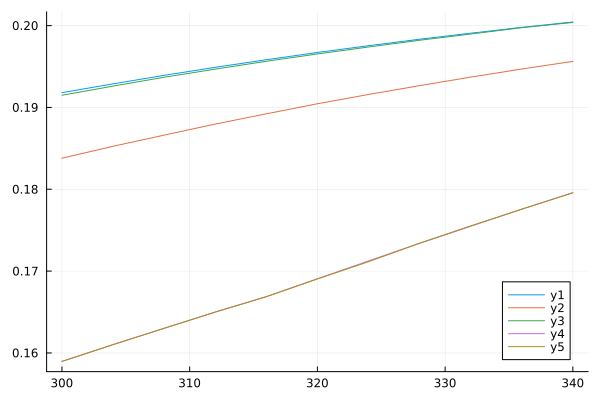

In [68]:
plot!(real(coff[2:end,2]),real(coff[2:end,3]))

In [ ]:
function caculate_cr()
    N_cheb = 199
    Ro = -1
    for Tw in (1.0)
        for Mr in (0.3:0.6)
            gamma = 1.4
            sigma = 0.72
            Co = 2-Ro-Ro^2
            num = 1
            F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)
            coff = [0 0 0 0 0]
            for n = 25 : 1 : 40
                c = c_A = 0.7
                for R = 200 : 2 : 400
                        omega = 0/R
                        be = n/R
                        Ma = Mr/R
                        hr=0.1;
                        ls=5;  
                        cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
                        L0_raw,L1_raw,L2_raw = assemble_mat(cof,D,D2,be,omega)
                        L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb)
                        nep = PEP([L0,L1,L2]);
                        eigval,eigvec = iar(nep, σ = c, neigs = 1,maxit = 500 , tol=1e-12)
                        c = real(eigval[1])
                        vel_full,vel = eig_full(eigvec,N_cheb,1)
                        
                        A0 = transpose(cof.D1) + (im * be * transpose(cof.B)) - (im * omega * transpose(cof.Ta)) - (be^2 * transpose(cof.Vyy)) - transpose(cof.dC) - (im *be*transpose(cof.dVyz)) + transpose(cof.d2Vzz) - (transpose(cof.C) + im * be * transpose(cof.Vyz) - 2 * transpose(cof.dVzz)) * kron(I(5),D) + transpose(cof.Vzz) * kron(I(5),D2)
                        A1 = (im * transpose(cof.A)) - (be * transpose(cof.Vxy)) - (im * transpose(cof.dVxz)) - (im * transpose(cof.Vxz)) * kron(I(5),D) 
                        A2 = -transpose(cof.Vxx)
                        L0_A,L1_A,L2_A = boudary_condition(A0,A1,A2,N_cheb)
                        nep1 = PEP([L0_A,L1_A,L2_A]);
                        eigval_A,eigvec_A = iar(nep1, σ = c_A, neigs = 1,maxit = 500 , tol=1e-14)
                        c_A = real(eigval_A[1])
                        vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1)
                        # eigvec = eigvec./findmax(abs.(vel[3]))[1]
                        # eigvec_A = eigvec_A./findmax(abs.(vel_A[2]))[1]
                        vel_full,vel = eig_full(eigvec,N_cheb,1)  
                        vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1)

                        Hx=( hr*exp(-(eigval[1])^2/4 *ls^2)*sqrt(pi/ls))
                        u_wall = -(D*F)[1] *(1/2pi*im) * Hx
                        v_wall = -(D*G)[1] *(1/2pi*im) * Hx
                        w_wall = 0
                        rho_wall = -(D*rho)[1] *(1/2pi*im) * Hx
                        T_wall = -(D*T)[1] *(1/2pi*im) * Hx
                        item_2 = rho[1] * (D*vel_A[2])[1] * u_wall
                        item_3 = rho[1] * (D*vel_A[3])[1] * v_wall
                        item_5 = rho[1]^2 * (T[1]/sigma) * (D*(vel_A[5]))[1] * T_wall

                        Q = (transpose(eigvec_A[:,1]) * W * (L1 + (eigval[1] + eigval_A[1]) * L2) * eigvec[:,1])
                        BC =  item_2 + item_3 + item_5
                        Cr = abs(-im * BC/Q[1])
                        # coff = [coff;[R Cr real(eigval) imag(eigval) abs(Q[1]) abs(BC)]]
                        coff = [coff;[n R Cr real(eigval) imag(eigval)]]
                        writedlm("Cr_lof_$(Mr)_$(Tw).dat",coff[2:end,:])
                end
            end
        end
    end
end

In [ ]:
caculate_cr()